# BoardExtractor probe: one decision

Plays a random game up to **one** decision, runs `BoardExtractor` on that single observation, and shows:

1. the **raw observation** (what the engine sends),
2. the **extracted board**: 22 slots decoded back to names, plus the globals,
3. the **arrays** the model actually receives.

Change `SEED` / `TURN` / `CONTEXT` in the next cell to look at a different decision.

| slots | 0 | 1–8 | 9 | 10–17 | 18 | 19 | 20 | 21 |
|---|---|---|---|---|---|---|---|---|
| what | my Active | my Bench | opp Active | opp Bench | Stadium in play | Supporter played this turn | Energy attached this turn | Stadium played this turn |

Run it with the `kaggle-pokemon` kernel, from `rl-train/model_v1/feature_extractor/`.

In [1]:
import sys
from pathlib import Path

HERE = Path.cwd()
RL_TRAIN = HERE.parents[1]
for p in (RL_TRAIN, RL_TRAIN / "engine", HERE):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

from helpers.helper import build_deck
from cg.api import SelectContext, SelectType, OptionType, AreaType
from cg.game import battle_finish, battle_select, battle_start

import board_extractor as bx
from board_extractor import BoardExtractor
from board_extractor_probe import check, random_choice

sns.set_theme(style="white")
pd.set_option("display.max_columns", 60, "display.width", 250, "display.max_colwidth", 40)

DECK0 = "./decks/main_agent.csv"
DECK1 = "./decks/opponents/dragapult_noir.csv"
deck0, deck1 = build_deck(DECK0), build_deck(DECK1)
extractor = BoardExtractor()  # normalize=True, as for training
print("card vocab size:", extractor.card_vocab_size)

card vocab size: 1434


## Helpers for showing one decision

- `raw_board(obs)` is the engine's view, by **absolute** seat.
- `decoded_table(features)` is the extractor's 22 slots, decoded back to names. It is relative to the **selecting** seat.
- `plot_arrays(features)` shows the arrays the model actually receives.

In [2]:
CARD_NAME = lambda cid: extractor.card_vocab[extractor._card_index(cid)]

def raw_board(obs: dict) -> pd.DataFrame:
    """Active + Bench of both seats, straight from the observation (absolute seats)."""
    rows = []
    for seat, player in enumerate(obs["current"]["players"]):
        for zone, pokemons in (("active", player["active"]), ("bench", player["bench"])):
            for i, pk in enumerate(pokemons):
                if pk is None:
                    rows.append({"seat": seat, "zone": zone, "index": i, "card": "<face down>"})
                    continue
                rows.append({
                    "seat": seat, "zone": zone, "index": i, "card": CARD_NAME(pk["id"]),
                    "hp": f'{pk["hp"]}/{pk["maxHp"]}',
                    "energy cards": ", ".join(CARD_NAME(e["id"]) for e in pk["energyCards"]),
                    "tools": ", ".join(CARD_NAME(t["id"]) for t in pk["tools"]),
                    "appearThisTurn": pk["appearThisTurn"],
                })
    return pd.DataFrame(rows)

def raw_state(obs: dict) -> pd.DataFrame:
    cur = obs["current"]
    flags = {k: cur[k] for k in ("turn", "yourIndex", "firstPlayer", "supporterPlayed", "energyAttached", "stadiumPlayed", "retreated")}
    flags["stadium"] = CARD_NAME(cur["stadium"][0]["id"]) if cur["stadium"] else "-"
    per_seat = {f"seat {s}": {"deck": p["deckCount"], "prizes left": len(p["prize"]), "hand": p["handCount"], "benchMax": p["benchMax"],
                              "conditions": ",".join(c for c in ("poisoned", "burned", "asleep", "paralyzed", "confused") if p[c]) or "-"}
                for s, p in enumerate(cur["players"])}
    return pd.DataFrame(flags, index=["state"]), pd.DataFrame(per_seat)

def options_table(obs: dict) -> pd.DataFrame:
    sel = obs["select"]
    rows = []
    for i, o in enumerate(sel["option"]):
        o = {k: v for k, v in o.items() if v is not None}
        o["type"] = OptionType(o["type"]).name
        me = obs["current"]["yourIndex"]
        # which board token the option points at (what a pointer-style policy would attend to)
        if "inPlayArea" in o:  # ATTACH / EVOLVE: the target Pokémon is always the selecting seat's
            o["-> board slot"] = bx.slot_of(o["inPlayArea"], o.get("inPlayIndex", 0), me, me)
            o["inPlayArea"] = AreaType(o["inPlayArea"]).name
        if "area" in o:
            o.setdefault("-> board slot", bx.slot_of(o["area"], o.get("index", 0), o.get("playerIndex", me), me))
            o["area"] = AreaType(o["area"]).name
        # PLAY / ATTACH / EVOLVE from the hand: name the hand card
        hand = obs["current"]["players"][me]["hand"] or []
        if o["type"] in ("PLAY", "ATTACH", "EVOLVE") and o.get("area", "HAND") == "HAND" and o.get("index", -1) < len(hand):
            o["card"] = CARD_NAME(hand[o["index"]]["id"])
        rows.append({"option": i, **o})
    # ints and names mixed with blanks: show as plain text, empty where an option has no such field
    return pd.DataFrame(rows).map(lambda v: "" if pd.isna(v) else str(int(v)) if isinstance(v, float) else str(v))

def decoded_table(features: dict) -> pd.DataFrame:
    df = pd.DataFrame(extractor.decode(features))
    df["conditions"] = df[bx.CONDITION_COLUMNS].apply(lambda r: ",".join(c[5:] for c, v in r.items() if v) or "", axis=1)
    df["tools"] = df[[f"tool_{i+1}" for i in range(bx.MAX_TOOLS)]].apply(lambda r: ", ".join(v for v in r if v != "<NONE>"), axis=1)
    df["energies"] = df[[f"att_e_{i+1}" for i in range(bx.MAX_ATTACHED_ENERGY)]].apply(lambda r: ", ".join(v for v in r if v != "<NONE>"), axis=1)
    cols = ["slot", "zone", "owner", "available", "card_id", "card_type", "subtype", "pokemon_type", "weakness", "stage",
            "hp", "max_hp", "retreat_cost", "appear_this_turn", "is_ex", "is_mega_ex", "is_tera", "is_special",
            "conditions", "tools", "energies"]
    return df[cols].set_index("slot")

def styled(df: pd.DataFrame):
    """Blue = my slots, red = opponent's, yellow = stadium / per-turn slots, grey text = empty, dark = masked."""
    def row_style(row):
        if not row["available"]:
            return ["background-color: rgba(0,0,0,.45); color: #888"] * len(row)
        if row["card_id"] == "<NONE>":
            return ["color: #aaa"] * len(row)
        if row["zone"] in ("STADIUM_IN_PLAY", "SUPPORTER_PLAYED", "ENERGY_PLAYED", "STADIUM_PLAYED"):
            return ["background-color: rgba(230, 190, 40, .25)"] * len(row)
        return [f"background-color: {'rgba(60,120,220,.18)' if row['owner'] == 'ME' else 'rgba(220,70,60,.18)'}"] * len(row)
    return df.style.apply(row_style, axis=1)

def globals_table(features: dict) -> pd.DataFrame:
    raw = features["globals"] * (extractor.GLOBAL_SCALE if extractor.normalize else 1)
    return pd.DataFrame([raw.round().astype(int).tolist(), features["globals"].round(3).tolist()],
                        index=["raw", "model input (normalized)"], columns=bx.GLOBAL_COLUMNS, dtype=object)

def plot_arrays(features: dict, title: str = ""):
    """The arrays as the model sees them: card indices, categorical indices, numeric values."""
    slot_labels = [f"{s:>2} {z[:4]}" + ("" if features["slot_mask"][s] else " (masked)") for s, z in enumerate(
        ["ME"] + ["ME"] * bx.MAX_BENCH + ["OPP"] + ["OPP"] * bx.MAX_BENCH + ["STAD", "SUP", "ENER", "STPL"])]
    cards = np.concatenate([features["card_ids"][:, None], features["tools"], features["energies"]], axis=1)
    card_cols = ["card_id"] + [f"tool{i+1}" for i in range(bx.MAX_TOOLS)] + [f"e{i+1}" for i in range(bx.MAX_ATTACHED_ENERGY)]
    card_annot = np.vectorize(lambda i: "" if i == 0 else extractor.card_vocab[i][:12])(cards)

    cat = features["categorical"]
    cat_annot = np.array([[bx.CATEGORICAL_VOCABS[c][v][:8] for c, v in zip(bx.CATEGORICAL_COLUMNS, row)] for row in cat])

    fig, axes = plt.subplots(1, 3, figsize=(26, 9), gridspec_kw={"width_ratios": [16, 7, 13]})
    sns.heatmap(cards > 0, annot=card_annot, fmt="", cbar=False, cmap="Blues", vmin=0, vmax=1.6, ax=axes[0],
                xticklabels=card_cols, yticklabels=slot_labels, linewidths=.5, linecolor="#eee", annot_kws={"size": 7})
    axes[0].set_title("card vocab indices (card_ids | tools | energies)\none shared nn.Embedding; 0 = <NONE>")
    sns.heatmap(cat, annot=cat_annot, fmt="", cbar=False, cmap="Greens", ax=axes[1],
                xticklabels=bx.CATEGORICAL_COLUMNS, yticklabels=False, linewidths=.5, linecolor="#eee", annot_kws={"size": 7})
    axes[1].set_title("categorical indices\none nn.Embedding per column")
    sns.heatmap(features["numeric"], annot=True, fmt=".2g", cbar=True, cmap="magma_r", vmin=0, vmax=1, ax=axes[2],
                xticklabels=bx.NUMERIC_COLUMNS, yticklabels=False, linewidths=.5, linecolor="#eee", annot_kws={"size": 7})
    axes[2].set_title("numeric (normalized) -> nn.Linear")
    for ax in axes:
        ax.tick_params(axis="x", rotation=60)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

## Get one decision

Random vs random from `SEED`, stopping at the first decision on turn `TURN` (or later) whose select context is `CONTEXT`.

In [3]:
SEED, TURN, CONTEXT = 0, 9, "MAIN"

def first_decision(seed: int, turn: int, context: str, max_steps: int = 5000) -> dict:
    rng = random.Random(seed)
    obs, _ = battle_start(deck0, deck1)
    extractor.reset()
    try:
        for step in range(max_steps):
            if obs["current"]["result"] != -1:
                raise RuntimeError("game ended before reaching that decision")
            # every decision goes through the extractor: slots 19-21 are tracked from the logs
            features = extractor(obs)
            if obs["current"]["turn"] >= turn and SelectContext(obs["select"]["context"]).name == context:
                return {"step": step, "seat": obs["current"]["yourIndex"], "turn": obs["current"]["turn"],
                        "context": context, "obs": obs, "features": features,
                        "problems": check(extractor, obs, features)}
            obs = battle_select(random_choice(obs["select"], rng))
    finally:
        battle_finish()

rec = first_decision(SEED, TURN, CONTEXT)
print(f"decision #{rec['step']}: seat {rec['seat']}, turn {rec['turn']}, context {rec['context']}")
print("consistency check:", rec["problems"] or "arrays match the raw observation")

decision #45: seat 1, turn 9, context MAIN
consistency check: arrays match the raw observation


## 1. Raw observation

In [4]:
obs = rec["obs"]
state, per_seat = raw_state(obs)
display(state, per_seat)
display(Markdown("**Board** (absolute seats)"), raw_board(obs))
display(Markdown("**Options offered** (`-> board slot` = the token this option points at)"), options_table(obs))

,turn,yourIndex,firstPlayer,supporterPlayed,energyAttached,stadiumPlayed,retreated,stadium
state,9,1,1,False,False,False,False,Jamming Tower


,seat 0,seat 1
deck,42,39
prizes left,6,6
hand,3,4
benchMax,5,5
conditions,-,-


**Board** (absolute seats)

,seat,zone,index,card,hp,energy cards,tools,appearThisTurn
0,0,active,0,Froslass,90/90,Basic {D} Energy,,False
1,0,bench,0,Marnie's Impidimp,70/70,"Basic {D} Energy, Basic {D} Energy",,False
2,0,bench,1,Yveltal,100/110,,,False
3,1,active,0,Dreepy,70/70,"Basic {R} Energy, Basic {P} Energy, ...",,False
4,1,bench,0,Budew,30/30,Basic {P} Energy,,False


**Options offered** (`-> board slot` = the token this option points at)

,option,type,area,index,inPlayArea,inPlayIndex,-> board slot,card,attackId
0,0,EVOLVE,HAND,0,ACTIVE,0,0,Drakloak,
1,1,ATTACH,HAND,2,ACTIVE,0,0,Basic {R} Energy,
2,2,ATTACH,HAND,2,BENCH,0,1,Basic {R} Energy,
3,3,ATTACH,HAND,3,ACTIVE,0,0,Basic {R} Energy,
4,4,ATTACH,HAND,3,BENCH,0,1,Basic {R} Energy,
5,5,ATTACK,,,,,,,150
6,6,ATTACK,,,,,,,151
7,7,RETREAT,,,,,,,
8,8,END,,,,,,,


## 2. Extracted board, decoded

Relative to the selecting seat: ME = the seat choosing. Blue = my slots, red = the opponent's, yellow = stadium / per-turn slots, grey text = empty.

**Dark rows are masked** (`available = 0`, `slot_mask` False): Bench slots past that player's `benchMax`, which do not exist, so attention ignores them. Empty slots that *do* exist (an open Bench spot, a Supporter not yet played) stay as normal tokens.

In [5]:
display(styled(decoded_table(rec["features"])))
display(Markdown("**Globals** (become the global token)"), globals_table(rec["features"]))

,zone,owner,available,card_id,card_type,subtype,pokemon_type,weakness,stage,hp,max_hp,retreat_cost,appear_this_turn,is_ex,is_mega_ex,is_tera,is_special,conditions,tools,energies
slot,,,,,,,,,,,,,,,,,,,,
0,ACTIVE,ME,1,Dreepy,POKEMON,NONE,DRAGON,NONE,BASIC,70,70,1,0,0,0,0,0,,,"Basic {R} Energy, Basic {P} Energy, Basic {D} Energy"
1,BENCH,ME,1,Budew,POKEMON,NONE,GRASS,FIRE,BASIC,30,30,0,0,0,0,0,0,,,Basic {P} Energy
2,BENCH,ME,1,,SPECIAL,NONE,NONE,NONE,NONE,0,0,0,0,0,0,0,0,,,
3,BENCH,ME,1,,SPECIAL,NONE,NONE,NONE,NONE,0,0,0,0,0,0,0,0,,,
4,BENCH,ME,1,,SPECIAL,NONE,NONE,NONE,NONE,0,0,0,0,0,0,0,0,,,
5,BENCH,ME,1,,SPECIAL,NONE,NONE,NONE,NONE,0,0,0,0,0,0,0,0,,,
6,BENCH,ME,0,,SPECIAL,NONE,NONE,NONE,NONE,0,0,0,0,0,0,0,0,,,
7,BENCH,ME,0,,SPECIAL,NONE,NONE,NONE,NONE,0,0,0,0,0,0,0,0,,,
8,BENCH,ME,0,,SPECIAL,NONE,NONE,NONE,NONE,0,0,0,0,0,0,0,0,,,


**Globals** (become the global token)

,turn_number,my_deck,my_prizes,my_hand,my_bench_max,opp_deck,opp_prizes,opp_hand,opp_bench_max,is_my_turn,went_first,retreated_this_turn
raw,9,39,6,4,5,42,6,3,5,1,1,0
model input (normalized),0.3,0.65,1.0,0.2,0.625,0.7,1.0,0.15,0.625,1.0,1.0,0.0


## 3. Arrays the model receives

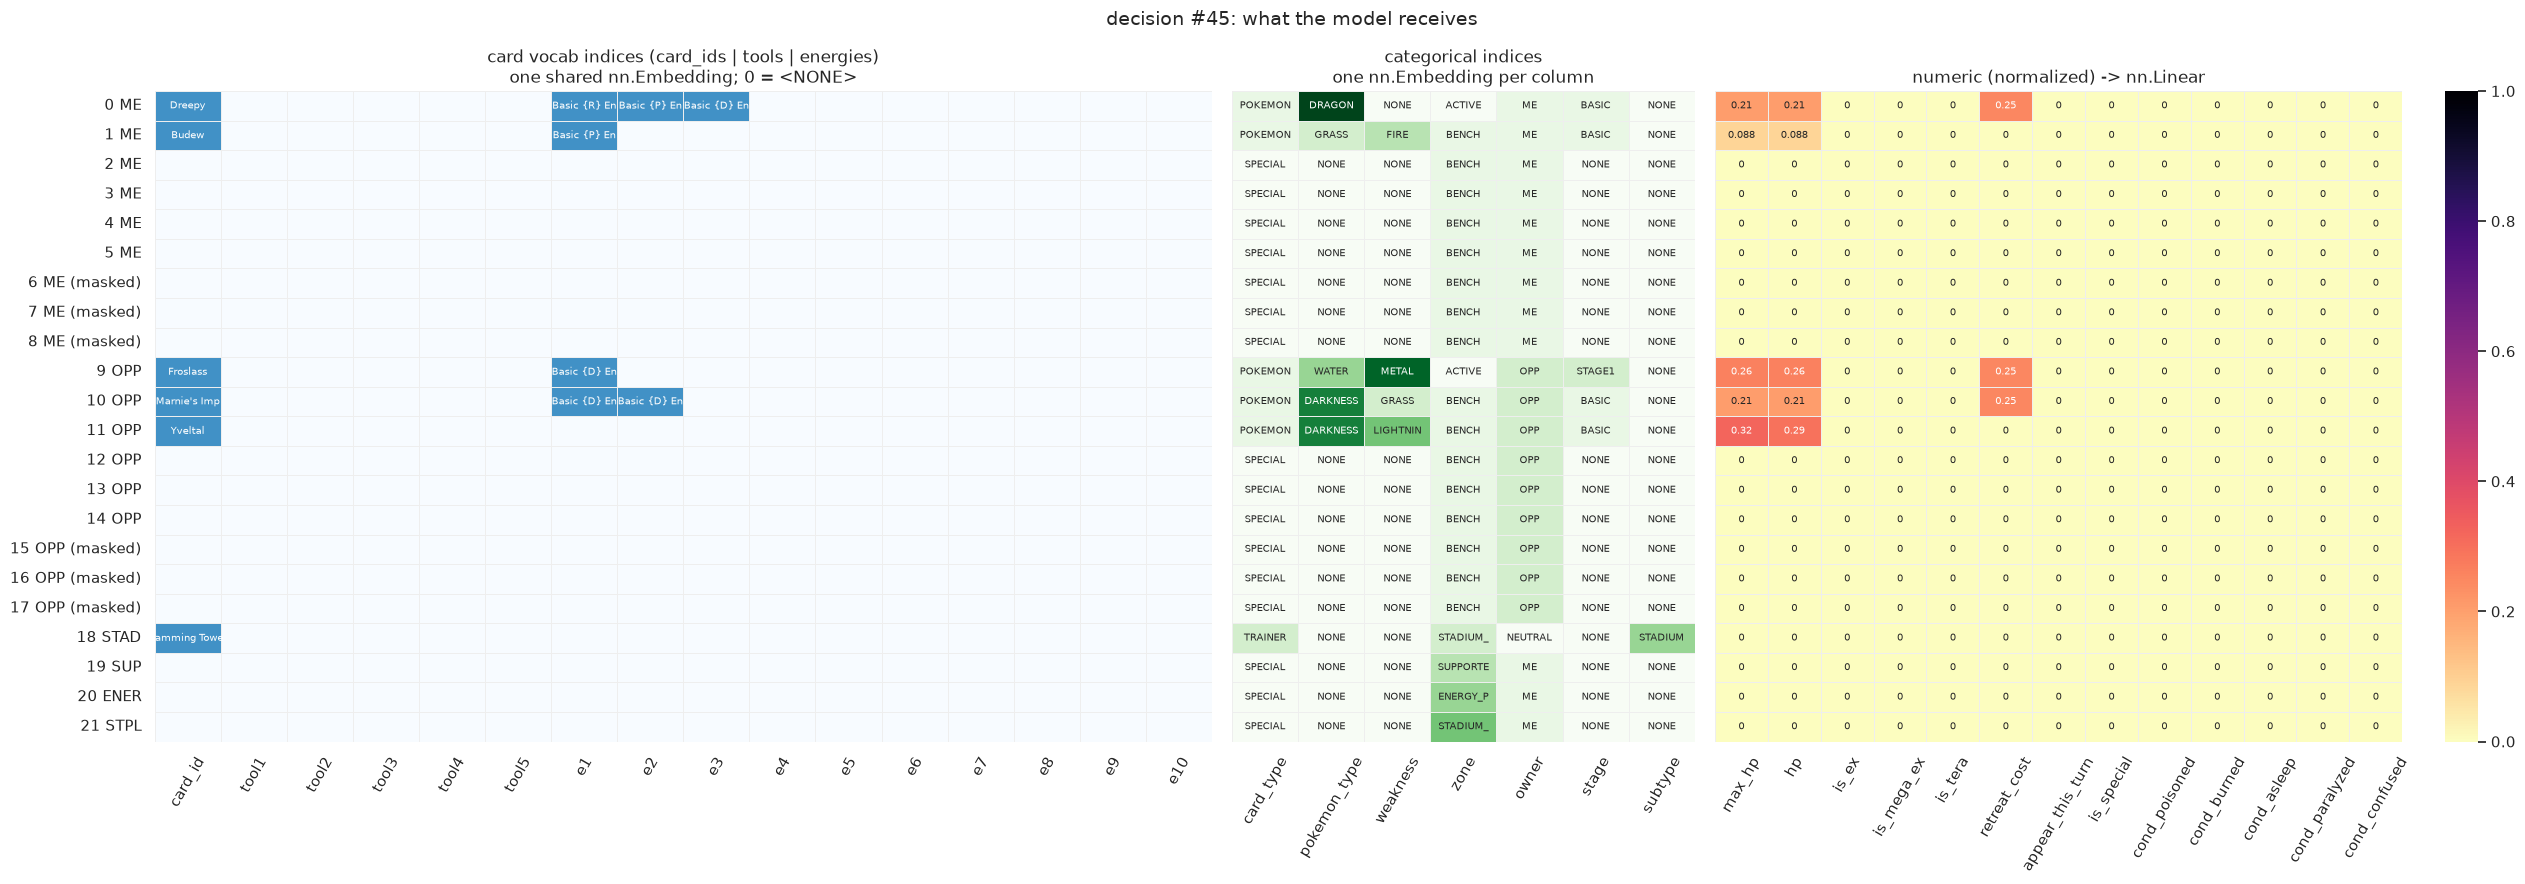

In [6]:
plot_arrays(rec["features"], f"decision #{rec['step']}: what the model receives")

In [7]:
np.set_printoptions(linewidth=200, suppress=True, precision=3)
for key, arr in rec["features"].items():
    print(f"{key} {arr.shape} {arr.dtype}")
    print(arr, end="\n\n")

card_ids (22,) int64
[ 121  237    0    0    0    0    0    0    0  106  648  691    0    0    0    0    0    0 1248    0    0    0]

tools (22, 5) int64
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]

energies (22, 10) int64
[[4 7 9 0 0 0 0 0 0 0]
 [7 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [9 0 0 0 0 0 0 0 0 0]
 [9 9 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

categorical (22, 7) int64
